# Building a Language Model

$$\newcommand{\ket}[1]{\left|{#1}\right\rangle}$$
$$\newcommand{\bra}[1]{\left\langle{#1}\right|}$$
$$\newcommand{\braket}[2]{\left\langle{#1}\middle|{#2}\right\rangle}$$
$$\DeclareMathOperator{\exp}{exp}$$
$$\newcommand{\fint}[1]{\int \! \mathcal{D}{#1}}$$
$$\DeclareMathOperator*{\argmax}{arg\,max\,}$$

## Problem Statement
Language data are sequences of symbols, or "tokens". There is probably a more general physical process that is continuous which ought to be assigned to the notion of "language", but digitial writing is naturally discretized/tokenized by the set of unique characters used to create a digital corpus in the first place. Text is thus described as a sequence of tokens $(x(1), x(2), x(3), \ldots)$ where each $x(t)$ is drawn from a set of $D$ different tokens

$$x(t) \in \{e_1, e_2, \ldots, e_D \}.$$

This set is generally called the "vocabulary" since historically people with slow computers and fuzzy ideas thought about using whole words as tokens, but in modern times it seems more natural to call it an "alphabet".

Given a sequence $(x(1), x(2), x(3), \ldots, x(t))$, we aim to generate a reasonable continuation of the sequence by predicting the token $x(t+1)$ that should come next. We will do this by computing a probability distribution over the possible states $x(t+1)$ could take, conditional on the previous states

$$P\big(x(t+1) \mid x(1), x(2), x(3), \ldots, x(t)\big).$$

## Tokens and Embedding

In order to compute anything, we need additional quantitative structure for our language elements.

We want to compute probability functions over sets of input tokens, and to do so we need to assign our tokens to numbers. How to do this? We do this almost automatically by counting them and assigning the $D$ elements of our alphabet to the integers $1,2,\ldots,D$. Thats technically enough to define numerical inputs which we can define functions over. That is, it gives us sequences of the form e.g.

\begin{align}
(x(1), x(2), x(3), \ldots x(t) ) & = (4,9,5,\ldots, 8) \\
& = \vec{v}
\end{align}

as input vectors, for which we can try to approximate functions $P_d(\vec{v})$ for the probability that $x(t+1)$ should be $d$.

But clearly this isn't a unique mapping, and it has some odd properties. This makes some tokens' numerical representation larger than others, and closer or further from all the other tokens depending on the index order we picked. Instead of just mapping to distinct numbers, we can assign the $D$ elements in our alphabet to $D$ distinct points (i.e., embed) in some vector space. The probability functions we want to construct are then functions with that vector space as a domain. 

The natural embedding is then to represent our alphabet with the unit vectors in $D$ dimensions i.e. $\hat{e}_1 = (1,0,0,\ldots)$, $\hat{e}_2 = (0,1,0,0, \ldots)$, etc. This now has the intuitively satisfying property that every token $\hat{e}_i$ has the same sense of distance from any other $\hat{e}_j$, without regard to our indexing choice.  Our text data is then described by sequences of unit vectors $\big(\vec{x}(1), \vec{x}(2), \vec{x}(3), \ldots \big)$ where each sequence element is an element of the alphabet,

$$\vec{x}(t) \in \{\hat{e}_1, \hat{e}_2, \ldots, \hat{e}_D \}.$$

We then find that the probability over possible next-tokens is a time dependent vector in the basis of our token representations

$$\vec{P}(t) = \sum_{d=1}^D P_d(t) \hat{e}_d.$$

There is then a further abstraction to be made here, which is actually relevant to understanding aspects of the sucessful language model approximation functions. Instead of Euclidean unit vectors, we can identify our alphabet elements with a set of orthonormal functions $f_d(\theta)$, embedding in a Hilbert space with
$$ \int d\theta f_d(\theta) f_{d'}(\theta) = \delta_{dd'}.$$


Our probability vector is then represented by
$$P(\theta, t) = \sum_{d=1}^D P_d(t) f_d(\theta),$$

where the probabilities of interest are extracted from this representation by 
$$P_d(t) = \int d\theta f_d(\theta) P(\theta, t).$$

What basis is best, then? In a sense we can always start with the Euclidean representation $\hat{e}_d$, and then transform to a different basis set like $f_d(\theta)$. Further, we can let the functions $f_d(\theta)$ be variables which we fit for. This simply ends up being the first linear transformation in the model, to be followed by other transformations that compose the more complex approximation function.

## The Probability Function(al)

Our probability distribution of interest is a function over the whole history of the input sequence $\vec{x}(\tau)$ for $\tau \leq t$, which we write as $P_d\big(t, [\vec{x}(\tau)]\big).$

Everything must be discretized for digital computation eventually, but its best not to discretize too early. While I asserted above that our data is naturally discretized, it is still the image of underlying continuous physical processes. So consider paths $\vec{x}(\tau)$ through the state space over continuous time $\tau$.

**Functionals**:
"A functional is a number whose value depends on specifying a complete function. For example, the area under a curve is a functional of the curve: $A = \int f(y) dy$. To find it, a function (the curve) must be specified. We write a functional as $A[f(y)]$ to indicate that $A$ depends on the function $f(y)$. We do not write $A(f(y))$, for that might be interpreted as a function of a function, i.e. that $A$ just depends what value $f$ takes a some specified point $y$. This is not the case. $A[f(y)]$ depends on the entire shape of the function $f(y)$. It does not depend on $y$ in any way." - from Feynman and Hibbs p.g. 68

In our case we use the notation $P_d(t, [\vec{x}(\tau)])$ to keep track of how it is also a normal function of the coordinate $t$.

For several reasons, its better to approximate the log-probabilities $a_d$ defined by
$$P_d\big(t, [\vec{x}(\tau)]\big) \propto \exp\big( a_d(t, [\vec{x}(\tau)]) \big).$$

Since we're only really interested in the relative probabilities, we don't care about the normalization. 

Our objective is thus to find an approximation for a vector-valued functional
$$\vec{a}\big(t, [\vec{x}(\tau)] \big) = \sum_{d=1}^D a_d\big(t, [\vec{x}(\tau)] \big) \hat{e}_d$$

that fits our data in the maximum likelihood sense - for each $t$ we want
$$\argmax_d \, a_d\big(t, [\vec{x}(\tau)] \big) = \argmax_d \, x_d(t).$$
If each $\vec{x}(t)$ is a unit vector, this corresponds to optimizing an objective function
$$\sum_t \vec{a}\big(t, [\vec{x}(\tau)]\big) {\cdot} \vec{x}(t).$$

Well, actually we want a bit more than that. We also want some sense of reasonable exursions around that peak ("generalization").

Achieving this depends on assumptions, whether they be carefully stated and understood or not, that are encoded in the model by the choices in the structure of the approximation model that restrict the space of possibe functions that can fit the data.

## Function Approximation

The basic (or maybe "classic" these days) approach to modeling a complicated function $f(x)$ is to approximate it as a linear combination of simpler basis functions
$$f(x) \approx \sum_n c_n \sigma(x, \vec{\theta}_n)$$

where the $\vec{\theta}_n$ dependence describes generally specification of some set of basis elements out of some larger set. The basis might be Fourier modes $\sigma(x, \omega_n) = e^{i \omega_n x}$, or radial basis functions $\sigma(x, \bar{x}_n, \epsilon) = g(\epsilon |x - \bar{x}_n|)$.

There are a plethora of possibilities developed over the years that have some universal approximation capacity, but will have different properties in finite limits. These differences amount to different priors on the function to be approximated, and may or may not be important for a particular problem. Additionally, different bases may admit more or less practical and performant algorithms for fitting the parameters.

Of the many possibilities, spline functions are a go-to for their stability in fitting data with any scattered sampling points $x_n$. Splines in 1D or 2D are perhaps most often associated with compact "B-spline" basis functions which admit efficient algorithms, but there is an alternative basis for the same functions. A spline of degree $p$ can be written as
$$ S(x) = \sum_n c_n (x - \bar{x}_n)^p_+ + \sum_{j=0}^p \beta_j x^j,$$
where
$$(z)^p_+ = \operatorname{max}(0, z)^p$$

is known as the "truncated power" function. Of course, $p=1$ is more widely known now as the "rectified linear unit" $\operatorname{ReLU}(z) = (z)_+ = \operatorname{max}(0, z)$.

Beyond two or three dimensions the curse of dimensionality makes naive tensor product splines too expensive to be widely useful. An alternative view of splines in the truncated power basis is as a case of the more general class of ridge functions, with basis functions of the form $\sigma(w_n x + b_n)$. As another example, the real Fourier series can also be seen as an expansion in ridge functions $\cos(w_n x + b_n)$. In multiple dimensions $\vec{x}$ in $\mathbb{R}^d$, this generalizes to $\sigma(\vec{W}_n \cdot \vec{x} + B_n)$. For vector functions $\vec{F}(\vec{x}): \mathbb{R}^d \rightarrow \mathbb{R}^n$ we use expansions in ridge functions of the form
$$\vec{F}(\vec{x}) = \sum_k \vec{V}_k \sigma\big( \vec{W}_k {\cdot} \vec{x} + B_k\big).$$

and in particular ridge splines with $\sigma(z) = max(0, z)^p$.

## Functional Approximation

We're interested in approximating functionals $F[\vec{x}(\tau)]$ over paths $\vec{x}(\tau)$. Rigorously handling functionals can get mathematically subtle, but working by intuitive analogy works fine for present crude purposes. Consider a formal Fourier representation of $F$ as
$$F[\vec{x}(\tau)] = \int \mathcal{D}\vec{q}(\tau)\varphi[\vec{q}(\tau)] e^{i \int d\tau \vec{q}(\tau) \cdot \vec{x}(\tau) },$$
where $\int \mathcal{D}\vec{q}(\tau)$ means integrate over a whole space of functions $\vec{q}(\tau)$, and the functional $\varphi$ is the Fourier transform of $F$ (if $F$ is a probability distribution, $\varphi$ is the characteristic function).

As one does for any integral one would like to approximate, we suppose that there is an approximation by a quadrature rule with weights $c_k$ and nodes $\vec{w}_k(\tau)$ as
$$F[\vec{x}(\tau)] \approx \sum_k c_k \varphi[\vec{w}_k(\tau)] e^{i \int d\tau \vec{w}_k(\tau) \cdot \vec{x}(\tau) },$$

which we can rewrite as (assuming real $F$)
$$F[\vec{x}(\tau)] \approx \sum_k v_k \cos\bigg(\int d\tau \vec{w}_k(\tau) \cdot \vec{x}(\tau) + b_k\bigg).$$

This generalizes to bases of ridge functionals $\sigma\big(\int d\tau \vec{w}_k(\tau) \cdot \vec{x}(\tau) + b_k\big)$ i.e.
$$F[\vec{x}(\tau)] = \int \mathcal{D}\vec{q}(\tau)\varphi[\vec{q}(\tau)] \sigma\bigg( \int d\tau \vec{q}(\tau) \cdot \vec{x}(\tau) + B[\vec{q}(\tau)] \bigg),$$
and hence approximations like
$$F[\vec{x}(\tau)] \approx \sum_k v_k \sigma\bigg(\int d\tau \vec{w}_k(\tau) \cdot \vec{x}(\tau) + b_k\bigg),$$

in obvious analogy to the finite dimensional construction in the previous section. 

If we simply approximate the integral $\int d\tau \vec{w}_k(\tau) \cdot \vec{x}(\tau)$ by e.g. a basic Riemmann sum, then we have reduced to the finite dimensional form, just with the input domain the vectorization $\operatorname{Vec}(x)$ of a matrix $x_{d\tau}$. That is, discretization of the integral over dot-products of vector-valued functions becomes an inner-product of matrices $\sum_d \sum_\tau w_{kd\tau} x_{d\tau}$.

But there is a point to the more general functional view of things. It is the right formal description for reasoning over general properties and symmetry priors that should be built into our model. Once thats established, appropriate discretization for efficient numerical evaluation follows. On the other hand, if we want to develop an numerical implementation with available computing hardware/software, we have to be cognizant of those limitations which will further constrain the space of models amenable to computation. The consideration flows both ways - understanding high level continuous symmetries and constraints of the problem can lead to realized models that accomplish more with finite computing resources.

Getting back to our specific problem, it would seem to follow that we consider approximations for the log-probabilities as
$$\vec{a}\big(t, [\vec{x}(\tau)] \big) = \sum_k \vec{V}_k(t) \sigma\bigg( \int_0^t d\tau \vec{W}_k(\tau) \cdot \vec{x}(\tau) + B_k \bigg).$$

This looks superficially like an analogous approximating expansion - our output space is the set of paths $\vec{a}(t)$, so we put in coefficients $\vec{V}(t)$ to match. But its missing something, since
\begin{align}
\vec{a}\big(t, [\vec{x}(\tau)] \big) & = \sum_k \vec{V}_k(t) y_k(t), \\
& \text{ where } y_k(t) = \sigma\bigg( \int_0^t d\tau \vec{W}_k(\tau) \cdot \vec{x}(\tau) + B_k \bigg).
\end{align}

In this form we can see how the inner-product (the sum over $k$ with outer coefficients $\vec{V}_k(t)$) ignores the $t$ coordinate, which should be included. The autoregressive nature of our model seems to force $t$ to appear as a coordinate in the inner linear transformation, and thus the approximation should take the form 
$$a_d\big(t, [\vec{x}(\tau)] \big)  = \sum_k \int_0^t dt' V_{dk}(t, t') \sigma\bigg( \sum_m \int_0^{t'} d\tau W_{km}(t', \tau) x_m(\tau) + B_k \bigg).$$
Spelled out in explicit index notation, this is the appropriate multi-way analogue of our vector function approximating expansion - $V$ is a linear transformation of vectors on the coordinates $(k, t')$ to vectors on the coordiantes $(d, t)$.

But now we can recognize another issue with this form - there is an absolute dependence on $t$, wheras it is clear that our model ought to be time-translation invariant. This is an important aspect of constraing our model fit to a finite set of data in a way the might generalize in a way that makes us happy.

So, we restrict the models linear transformation parameters to be translation invariant over time, which makes them convolutions,
$$a_d\big(t, [\vec{x}(\tau)] \big)  = \sum_k \int_0^t d\tau V_{dk}(\tau - t) \sigma\bigg( \sum_m \int_0^{\tau} d\tau' W_{km}(\tau' - \tau) x_m(\tau') + B_k \bigg).$$

In principle, this is a universal approximator for a class of functions we want to model - as long as we make the $k$ dimension sufficiently large (i.e. use a sufficient number of basis functions). Ridge functions may propose to free us from the tyranny of treating fixed orthogonal coordinate axes as equally special in high dimensions, but they don't intrinsically alleviate the curse of dimensionality. Generically, we may need an exponentially large number of basis functions in this expansion. 

The way to potentially overcome this hurdle is what has come to be popularly known by the marketing term "deep learning". 

## Composite Functions ("Deep Learning")

The core mathematical idea underlying "deep learning" and "deep neural networks" is to approximate a complicated function $f(x)$ by composition of a series of relatively simpler non-linear functions
$$f(x) = (f_{L-1} \circ f_{L-2} \circ \ldots \circ f_0)(x),$$
which could also be expressed as a recursive series of transformations
$$x_{\ell+1} = f_\ell(x_\ell), \text{ with } f(x) = x_{L}, \text{ } x_1 = x, \text{ for } 0 \leq \ell \leq L-1.$$

Composition is a further way of building assumptions - addtional priors on the space of functions - in to the approximation model. If the true function appears extremely complex, in the sense that its naive Fourier expansion would require an exponentially large number of modes, we may still beat the curse of dimensionality if the apparent complexity is actually generated by a heirarchical composition of simpler functions.

Composite functions will not somehow magically allow you to interpolate pure noise in high dimensions for an exponentially reduced computational cost. But the functions that describe things we actually care about are not pure noise, so this turns out to be a good generally applicable prior. Things like text, images, video, speech, etc, are generically more structured because they are images of physical processes which have natural heirarchical structure.

The first-degree splines, i.e. continuous piecewise-linear functions, provide a useful prototype for building some intuition for the composite functions. Recall that a first-degree spline can be written as
$$f(x) = \sum_{k=1}^{N} v_k (x - b_k)_+$$
and suppose that we construct a function $g(x)$ as a composition of $L$ such functions 
$$g(x) = (f_L \circ f_{L-1} \circ \ldots \circ f_1)(x).$$

It happens that a composition $f_2 \circ f_1$ of two piecewise-linear functions is again a piecewise linear function, and so the composite function $g(x)$ has an equivalent expression as
$$g(x) = \sum_{m=1}^{M} w_m (x - c_m)_+$$

for some set of new parameters $w_m$,$c_m$. In particular, the number $M$ of breakpoints/nodes created by the composition can grow exponentially with the depth $M \sim N^L$, and generally adding nodes is how you make an arbitrarily good approximation. 

Of course, there's no free lunch here. The distribution of these break points will be correlated, so you can't arrange them in arbitrary patterns to match arbitrary functions by changing the underlying layer parameters. But for natural functions with multiscale correlation structure, it is difficult know how to place nodes algorithmically in the first place. For a function with varying smoothness over its domain, generally you need more nodes where the function is rough, and fewer where it is smooth. I think this is one way of looking at what composition buys you - a kind of built-in clustering. In order to find such a distribution algorithmically with a single-layer model, generally some of the location paramters would require large changes from their initial positions. But with a composite structure, the output structure can be built out of smaller changes to the parameters in the constituent layers. This allows you to approximate what looks on the surface as a highly complex function more efficiently than would a flat expansion as a linear combination.

This picture generalizes to multivariate ridge splines, and of higher degree. For multivariate first-degree ridge splines
$$\vec{F}_\ell(\vec{x}) = \sum_{k=1}^N \vec{V}_{\ell,k} \big(\vec{W}_{\ell,k} \cdot \vec{x} + B_{\ell,k} \big)_+^p$$
with $p=1$, the composition defined by $\vec{x}_{\ell+1} = \vec{F}_\ell(\vec{x}_\ell)$ is again a piecewise-linear function which partitions the input domain adaptively.

For higher degree $p > 1$ composite splines, the composite function is actually smoother than its constituents - the composition of a spline with degree $p$ and a spline of degree $p'$ is a spline of degree $p p'$. So it seems a few layers can construct a function that is very smooth where it needs to be, in a way that that robustly adapts to the data sampling.

## Exact Renormalization Group Flow
The exact renormalization group (ERG) flow is a mathematical tool developed by physicists for quantum field theory which exhibits precisely this kind of compositional structure in service of handling probability density functionals. The density functional for a real scalar field $\phi(x)$ over $x \in \mathbb{R}$ is defined through the action $S[\phi]$ as
$$P[\phi] = \frac{e^{-S[\phi]}}{\int \mathcal{D}\phi e^{-S[\phi] } }$$

and an ERG flow is defined by a sequence of infinitesimal reparameterizations
$$\phi_{\lambda + \delta\lambda}(x) = \phi_\lambda(x) + \delta\lambda \Psi_\lambda\big(x, [\phi_\lambda]\big),$$
which is a functional differential equation
$$\frac{\partial}{\partial \lambda} \phi_\lambda(x) = \Psi_\lambda\big(x, [\phi_\lambda]\big),$$

which induces a flow $\partial_\lambda S_\lambda[\phi_\lambda]$  of the action that preserves the partition function. A general form of $\Psi$ is
$$\Psi_\lambda\big(x, [\phi_\lambda] \big) = -\int dy K_\lambda(y - x) \frac{\delta \Sigma_\lambda[\phi_\lambda]}{\delta \phi_\lambda(y)}$$
where $K_\lambda(y - x)$ is the "ERG kernel" (and needs be positive-definite?), and
$$\Sigma_\lambda[\phi_\lambda] = S_\lambda[\phi_\lambda] - \frac{1}{2} \int dx \int dx' \phi_\lambda(x) C^{-1}_\lambda(x - x') \phi_\lambda(x')$$

In the standard QFT context $K$ is chosen to be related to $C$ by a derivative, but in general there is freedom in defining the reparameterization scheme. The question is what properties it can produce in the solutions, and whether they are physically appropriate - but we don't have such constraints here (or we should, but don't know what they are yet). With just a bit of tinkering, we will see how the ERG flow produces composite function approximations we want for our language modeling problem. Which is to be expected - conceptually, one might say machine learning is just trying to do for general human-scale problems what field theory was developed to do for understanding fundamental physical interactions.

We can map our language modeling problem on to this formalism by making our fields vector fields $\vec{\phi}(x)$, and identifying this with our state-space paths $\vec{x}(t)$. That is, we have one space-time coordinate time $t$ which we're calling $x$ here, wheras the vector components of the state seem more analagous to internal degrees of freedom i.e., spin-like.

Suppose we take the action to be
$$S_\lambda[\vec{\phi}_\lambda] = \int dx \sum_\mu G\big(\vec{\xi}_\mu \cdot \vec{\phi}_\lambda(x)\big),$$
where $G$ is some non-linear function and $\vec{\xi}_\mu$ are parameters. Note that this choice is local in $x$. We then choose to set $C^{-1}_\lambda(x - x') = \delta(x - x')$ so that

$$\frac{\delta \Sigma_\lambda[\vec{\phi}_\lambda]}{\delta \vec{\phi}_\lambda(y)} =  \sum_\mu \vec{\xi}_\mu G'\left(\vec{\xi}_\mu \cdot \vec{\phi}_\lambda(y) \right) - \vec{\phi}_\lambda(y)$$
with $G'$ the derivative of $G$, and the flow functional (now vector valued) is 
$$\vec{\Psi}_\lambda\big( x, [\vec{\phi}_\lambda] \big) = - \int dy K_\lambda(y - x) \left( \sum_\mu \vec{\xi}_\mu G'\big(\vec{\xi}_\mu \cdot \vec{\phi}_\lambda(y) \big) - \vec{\phi}_\lambda(y)\right).$$

If we discretize the differential equation in $\lambda$ by the basic Eulerian forward time-marching scheme over a finite interval $\lambda \in [0, 1]$ with $L$ steps, we get the recursion
$$\vec{\phi}_{\ell + 1}(x) = \vec{\phi}_{\ell}(x) + \frac{1}{L} \int dx' K_\ell(x' - x) \left(\vec{\phi}_\ell(x') - \sum_\mu \vec{\xi}_{\ell\mu} G'\left(\vec{\xi}_{\ell\mu} \cdot \vec{\phi}_\ell(x') \right) \right).$$

To summarize, the ERG flow defines a composite function which _transforms_ an intial vector field $\vec{\phi}_0(x)$ to a new vector field $\vec{\phi}_{L}(x)$.

Identifying $G'(z)$ with an activation function $\sigma(z)$, we can start to see how the general ERG flow basically produces the "transformer" architechture, in a generalized form. Not just in a vague sense of being a composite function or "deep neural network", but specifically producing the features of interleaving between a transformation layer which is local in time (the MLP layer), and a non-local time-time coupling layer (the attention layer), as well as "residual connections".

### Further Notes
-This form can also be seen to emerge from path-integral solutions to a non-linear Fokker-Planck equation, where $\frac{\delta S_\lambda}{\delta \phi}$ is related to the drift and $K_\lambda(x' - x)$ to the diffusion functions.

-Another useful connection is to the theory of associative memory - the action here is the associative memory energy function. Its all kind of the same thing in the end.

## The "Transformer" Architecture and "Attention Mechanisms"

We'll draw out the correspondence by translating the ERG flow notation into our language model notation. A composite function approximation for our log-probability function can be defined analagously by an $L$-layer recursion
$$\vec{x}_{\ell + 1}(t) = \vec{x}_\ell(t) + \int_0^t d\tau \mathbf{K}_\ell(\tau - t) \left(\vec{x}_\ell(\tau) - \vec{\psi}_\ell\left(\vec{x}_\ell(\tau) \right)  \right)$$
where we use bold font to denote that $\mathbf{K}$ is a matrix, and
$$\vec{\psi}_\ell(\vec{x}) = \sum_k \vec{V}_{\ell k} \sigma\left( \vec{W}_{\ell k} \cdot \vec{x} + B_{\ell k} \right).$$
Equivalently, we might write this with a more explicit interleaving of two types of layers as
\begin{align}
\vec{y}_\ell(t) & = \vec{x}_\ell(t) - \vec{\psi}_\ell\big(\vec{x}_\ell(t) \big) \\
\vec{x}_{\ell + 1}(t) & = \vec{x}_\ell(t) + \int_0^t d\tau \mathbf{K}_\ell(\tau - t) \vec{y}_\ell(\tau).
\end{align}

This is the basic form of the transformer architecture - the first transformation is an MLP layer, while the second is an "attention mechanism" that produces "time mixing". Popular examples have an additional residual connection, but there isn't going to be a practical difference. The main discrepancy at this point is here our time-time coupling matrices $\mathbf{K}_\ell$ are simply parameters, while the transformer attention matrix is a function of the current state vectors.

Generically, we need some form of time-time coupling matrix $\mathbf{K}(t, t')$ to build general approximating functions. Since we assume our model should be time symmetric, any such parameter matrix is restricted to be a convolution $\mathbf{K}(t, t') = \mathbf{K}(t - t')$. However, there is another way to obtain a time-time coupling matrix while keeping the model time symmetric. We can make it an _implicit_ function of time only through the variables $\vec{x}(t)$ as
$$\mathbf{K}(\vec{x}(t), \vec{x}(t')) = \mathbf{K}(\vec{z}_1, \vec{z}_2)\rvert_{\vec{z}_1 = \vec{x}(t), \vec{z}_2 = \vec{x}(t')}$$
so that the model specification is still for a translation invariant kernel $\mathbf{K}(\vec{z}_1, \vec{z}_2)$. The transformer's softmax attention is precisely such a function,
$$A\big(\vec{q}(t), \vec{k}(t'), [\vec{k}(\tau)] \big) = \frac{ \exp(\vec{q}(t) \cdot \vec{k}(t') )}{ \int_0^t d\tau \exp(\vec{q}(t) \cdot \vec{k}(\tau) )},$$
which is combined with a separate matrix factor that produces the "value" vectors.

The problem with this implicit time dependence is it makes the transformation
$$\vec{z}(t) = \int_0^t d\tau \mathbf{K}(\vec{x}(t), \vec{x}(\tau)) \vec{x}(\tau)$$
equivariant with respect to reorderings of the sequence $\vec{x}(t)$, which is not what you want for a language model which is based on a fundamental assumption of autoregressive causality. The fix for this is to add back in a relative time dependence to the kernel function as
$$\mathbf{K}(t' - t, \vec{z}_1, \vec{z}_2).$$

This is precisely what rotary positional embedding (RoPe) does. Applying RoPe to the querys/keys input to the softmax attention kernel makes it a particular case of time-time coupling matrix, so that a softmax-attention-with-RoPE transformer model is a case of the general form
\begin{align}
\vec{y}_\ell(t) & = \vec{x}_\ell(t) - \vec{\psi}_\ell(\vec{x}_\ell(t)) \\
\vec{x}_{\ell + 1}(t) & = \vec{y}_\ell(t) + \int_0^t d\tau \mathbf{K}_\ell\big(\tau - t, \vec{y}_\ell(t), \vec{y}_\ell(\tau) \big) \vec{y}_\ell(\tau).
\end{align}

There is nothing fundamental about the odd use of the softmax function in the transformer architecture. There are similarly smooth kernels that would have better numerical conditioning which would not require the awkward normalization, e.g. just use a Gaussian $\exp(-\tfrac{1}{2} \Vert \vec{q}(t) - \vec{k}(t') \Vert^2)$.

## Restriction to the Sphere

### Layer Normalization
The last practically important piece is layer normalization, which can be seen to follow from defining a model where evolution of the state vector over pseudo-time is restricted to the surface of a hypersphere $\mathbb{S}^{D-1}$. For a continuous flow on the sphere
$$\frac{\partial}{\partial \ell} \hat{x}_\ell(t) = \vec{F}_\ell(t, [\hat{x}_\ell(\tau)])$$
the $\vec{F}$ vector describes an infinitesimal rotation along a direction in the tangent space. The simple/intuitive way to approximate this evolution with discrete steps is to take small steps into the ambient space $\mathbb{R}^D$, and then project back to the sphere by normalization. The crude way to do this is a simple modification which just corresponds to normalization sub-steps as e.g.
\begin{align}
\vec{y}_\ell(t) & = \hat{x}_\ell(t) - \vec{\psi}_\ell(\hat{x}_\ell(t)) \\
\hat{y}_\ell(t) & = \frac{\vec{y}_\ell(t)}{\Vert \vec{y}_\ell(t) \Vert} \\
\vec{x}_{\ell + 1}(t) & = \hat{y}_\ell(t) + \int_0^t d\tau \mathbf{K}_\ell\big(\tau - t, \hat{y}_\ell(t), \hat{y}_\ell(\tau) \big) \hat{y}_\ell(\tau) \\
\hat{x}_{\ell + 1}(t) & = \frac{\vec{x}_{\ell + 1}(t)}{\Vert \vec{x}_{\ell + 1}(t)\Vert}.
\end{align}

### Bias Parameters

For $\vec{x} \in \mathbb{R}^D$ the location parameter $B_k$ of the ridge spline basis functions $(\vec{W}_k \cdot \vec{x} + B_k)^p_+$ acts as a radial translation with respect to the origin. When we restrict evolution to the hypersphere $\mathbb{S}^{D-1}$, the parameters kind of swap roles - the direction $\hat{W}_k$ is what sets the location on the sphere, while the ratio $\frac{B_k}{\vert \vec{W}_k \vert^p}$ effectively adjusts the angular width. With $B_k = 0$, the basis elements become angular bump-functions with fixed shape determined by $p$,
\begin{align}
(\vec{W}_k \cdot \hat{x})^p_+ & = \vert\vec{W}_k \vert^p (\hat{W}_k \cdot \hat{x})^p_+ \\
& = \vert\vec{W}_k \vert^p (\cos{\theta_k})^p_+, \text{ with } \theta_k = \arccos(\hat{W}_k \cdot \hat{x}) \in (0, \pi).
\end{align}
This makes the parameter $B_k$ somewhat (though not strictly) superfluous. In particular, these basis functions are angularly isotropic on the sphere with or without it. So the observation that a bias parameter is not helpful makes sense when combined with layer normalization.

## A Simple Language Model

We can build a simple model based on the ERG flow derived structure which is easily implemented with pytorch. 

First, there is a standard high dimensional vector embedding, which is trainable, but normalized i.e. the alphabet tokens are embedded in $N_{rep}$ dimensions on the sphere $\mathbb{S}^{N_{rep} -1}$. So our alphabet is represented as a set of $N_{alpha}$ unit vectors
$$\hat{u}_d \in \mathbb{S}^{N_{rep} - 1} \text{, for } d = 1, \ldots, N_{alpha}.$$

Then, denoting a discrete sequence with a fixed length $T$ by $\hat{x}_0(t)$, the model is a composition of $L$ layers as

\begin{align}
\vec{r}_{\ell}(t) & = \sum_{k=1}^{N_{nodes}} \vec{V}_{\ell k} \left(\vec{W}_{\ell k} \cdot \hat{x}_\ell(t) \right)^p_+, \\
\vec{x}_{\ell + 1}(t) & = \hat{x}_{\ell}(t) + \sum_{\tau=1}^t \mathbf{K}_\ell(\tau - t) \left( \hat{x}_{\ell}(\tau) - \vec{r}_\ell(\tau) \right), \\
\hat{x}_{\ell+1}(t) & = \frac{\vec{x}_{\ell + 1}(t)}{\Vert \vec{x}_{\ell + 1}(t) \Vert}
\end{align}

for $\ell = 0,\ldots, L-1$, and we have simply discretized the convolution integrals as Riemann sums. The final output for the $N_{alpha}$ log-probabilities (logits) is then
$$\vec{a}(t) = \mathbf{M} \hat{x}_{L}(t).$$

Along with the output projection matrix $\mathbf{M}$, the set of trainable parameters are the spline weights $\vec{V}_{\ell k}, \vec{W}_{\ell k}$, and the convolution kernels $\mathbf{K}_\ell(\tau)$.

The composition of relatively sparse layers builds up to an effectively dense total transformation. Empirically, the matrix structure of the kernels $\mathbf{K}_\ell(\tau)$ can be diagonal/block-diagonal with good effect. Using a diagonal form allows efficient use of FFTs for long convolutions ($\gtrsim 100$). For smaller convolution kernels, GPUs are good at doing the direct matrix multiplication, and the pytorch convolution functions allow easy use of a block-diagonal form. And since a composition of convolutions is again a convolution, both types can be composed to add some width while keeping the convolution kernel length long.

Rather than the standard weight decay regularization, for the convolution kernels we add a discrete Sobolev regularization term to the standard cross-entropy loss
$$ \lambda \sum_{\ell} \sum_\tau \Vert D^p \mathbf{K}_\ell(\tau) \Vert^2_2,$$
where $D^p$ is the $p$'th finite difference operator over $\tau$, i.e. $D \mathbf{K}_\ell(\tau) = \mathbf{K}_\ell(\tau) - \mathbf{K}_\ell(\tau-1)$. This is a prior that language sequences are not just random noise.

## Extensions

There are a range of obvious avenues to pursue from here, but thats for another day...

Ooooh, _thats_ what those "state-space" models are up to - to make a recursive form for sequential updates out of a convolution integral, you can formulate it as an ODE.

***
***
***

# Example

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as tnf

from torchaudio.functional import fftconvolve
from torch.utils.checkpoint import checkpoint
from torch.optim.lr_scheduler import LambdaLR

import time
import gc
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_data_path = 'shakespeare.txt'
with open(input_data_path, 'r', encoding='utf-8') as f:
    text = f.read()

sort_func = None
for _ in range(2):
    vocabulary = sorted(list(set(text)), key=sort_func)
    Nv = len(vocabulary)
    
    print(Nv)
    print(' '.join(vocabulary))
    print()
    
    stoi = {ch:ii for ii, ch in enumerate(vocabulary)}
    itos = {ii:ch for ii, ch in enumerate(vocabulary)}

    def encode(s):
        return [stoi[c] for c in s]

    def decode(l):
        return ''.join([itos[ii] for ii in l])

    assert decode(encode("hii there")) == "hii there"

    data = np.array(encode(text))

    histogram = np.histogram(data, bins=np.linspace(-0.5, Nv-0.5, Nv+1))[0]
    
    sort_func = lambda char : -histogram[stoi[char]]
    
data_gpu = torch.tensor(encode(text), dtype=torch.long).to(device)

def get_batch(batch_size, context_length):
    
    start_indices = torch.randint(len(data_gpu) - context_length, (batch_size,))
    x = torch.stack([data_gpu[ii:ii+context_length] for ii in start_indices])
    y = torch.stack([data_gpu[ii+1:ii+context_length+1] for ii in start_indices])
    # x, y = x.to(device), y.to(device)
    return x, y

65

   ! $ & ' , - . 3 : ; ? A B C D E F G H I J K L M N O P Q R S T U V W X Y Z a b c d e f g h i j k l m n o p q r s t u v w x y z

65
  e t o a h s r n i 
 l d u m y , w f c g I b p : . A v k T ' E O N R S L C ; W U H M B ? G ! D - F Y P K V j q x z J Q Z X 3 & $



In [3]:
def smooth_ramp(x, delta=0.1):
    x = x + 0.5*delta
    y_small = 0.5 / delta * x.square()
    y_big = x - 0.5*delta

    y = torch.where(x.abs() < delta, y_small, y_big)
    y = torch.where(x < 0.0, 0.0, y)
    return y

In [4]:
class TruncatedPower(nn.Module):
    
    def __init__(self, order, smooth=False):
        
        super().__init__()
        
        if order == 1 and smooth:
            sigma = lambda x: smooth_ramp(x, 0.1)
        elif order == 1:
            sigma = lambda x: torch.relu(x)
        elif order == 2:
            sigma = lambda x: torch.relu(x).square()
        elif order == 3:
            def sigma(x):
                xp = torch.relu(x)
                return xp*xp*xp
        else:
            sigma = lambda x: torch.relu(x).pow(order)
            
        self.sigma = sigma
        
    def forward(self, x):
        return self.sigma(x)

In [5]:
class Lambda(nn.Module):
    
    def __init__(self, func):
        super().__init__()
        self.func = func

    def forward(self, x):
        return self.func(x)

In [6]:
class RidgeSpline(nn.Module):
    
    def __init__(self, N_in, N_out, N_nodes, spline_order=1, bias=True, dropout=0.0):
        
        super().__init__()
        
        if spline_order == -1:
            self.sigma = TruncatedPower(1, smooth=True)
        else:
            self.sigma = TruncatedPower(spline_order, smooth=False)
#         self.sigma = Lambda(lambda x: x.square()*x)
        self.dropout = nn.Dropout(p=dropout)

        self.func = nn.Sequential(
            nn.Linear(N_in, N_nodes, bias=bias), self.sigma, self.dropout, nn.Linear(N_nodes, N_out, bias=False)
        )

    def forward(self, X):
        # X is (..., N_in)
        return self.func(X)

In [7]:
class DiagCausalConvolution(nn.Module):
    
    def __init__(self, N_dim, N_kernel):
        
        super().__init__()
        
        self.N_kernel = N_kernel
        
        self.W = nn.Parameter((2*torch.rand(1, N_dim, N_kernel) - 1) / (N_kernel)**0.5 )
        
        t_ax = torch.arange(N_kernel)/N_kernel
        taper = torch.exp(-2*(1- t_ax))
        self.register_buffer('taper', taper)
        
    def forward(self, X):
        
        # X is (batch, N_dim, Nt)
        return fftconvolve(X, self.W*self.taper, mode='full')[:,:,:X.shape[-1]] / self.N_kernel**0.5

In [8]:
class BlockedCausalConvolution(nn.Module):
    
    def __init__(self, N_in, N_out, N_kernel, N_groups):
        
        super().__init__()
        
        self.N_kernel = N_kernel
        self.N_groups = N_groups
        
        N_in_block = N_in // N_groups
        
        self.W = nn.Parameter((2*torch.rand(N_out, N_in_block, N_kernel) - 1) / (N_kernel*N_in_block)**0.5 )

    def forward(self, X):
        
        # X is (batch, N_in, Nt)
        # output is (batch, N_out, Nt)
        
        return tnf.conv1d(tnf.pad(X, (self.N_kernel-1, 0)), self.W, groups=self.N_groups) / self.N_kernel**0.5

In [9]:
def normalize(X):
    return X / torch.linalg.vector_norm(X, dim=-1, keepdim=True)

In [10]:
@torch.compile
class LayeredCausalConvSpline(nn.Module):
    
    def __init__(self, N_alpha, N_rep, N_nodes, N_kernel, N_kernel2, N_blocks, N_layers, spline_order=2):
        
        super().__init__()
        
        self.N_layers = N_layers
        self.N_rep = N_rep
        
        self.splines = nn.ModuleList([
            RidgeSpline(N_rep, N_rep, N_nodes, spline_order=spline_order, bias=False, dropout=0.0) for _ in range(N_layers)
        ])

#         self.convolutions = nn.ModuleList([
#             DiagCausalConvolution(N_rep, N_kernel) for _ in range(N_layers)
#         ])

        self.convolutions = nn.ModuleList([
            nn.Sequential(
                BlockedCausalConvolution(N_rep, N_rep, N_kernel2, N_blocks),
                DiagCausalConvolution(N_rep, N_kernel),
                BlockedCausalConvolution(N_rep, N_rep, N_kernel2, N_blocks)
            ) for _ in range(N_layers)
        ])

        self.embedding_matrix = nn.Embedding(N_alpha, N_rep)

        self.W_out = nn.Parameter((2*torch.rand(N_rep, N_alpha) - 1) / (N_rep)**0.5)
        
    def forward(self, x_sequences):
        X = self.embedding_matrix(x_sequences) # -> (batch, T, N_rep)
        
        for ll in range(self.N_layers):
            R = self.splines[ll](X)
            R = self.convolutions[ll]((X - R).swapaxes(-2,-1)) # -> (batch, N_rep, T)
                
            X = normalize(X + R.swapaxes(-2,-1)) # -> (batch, T, N_rep)
            
        return X @ self.W_out

In [11]:
N_rep = 128
N_nodes = 4*N_rep
N_kernel = 512
N_kernel2 = 8
N_blocks = N_rep//8
N_layers = 4

model = LayeredCausalConvSpline(Nv, N_rep, N_nodes, N_kernel, N_kernel2, N_blocks, N_layers, spline_order=3).to(device)

print("Number of parameters:", sum(p.numel() for p in model.parameters()))
print("Data size:", sum(p.numel() for p in model.parameters())*4*1e-6, "MB")
print()

input_test = torch.randint(0, 9, (32, 17)).to(device)
output_test = model(input_test)
output_test.shape

Number of parameters: 868608
Data size: 3.4744319999999997 MB



/lustre/aoc/projects/hera/zmartino/mambaforge/envs/transformers/lib/python3.11/site-packages/torch/_inductor/lowering.py:1713: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


torch.Size([32, 17, 65])

In [12]:
def sobolev_reg(model, p=2):
    terms = []
    for m in model.modules():
        if isinstance(m, DiagCausalConvolution):
#         if isinstance(m, BlockedCausalConvolution) or isinstance(m, DiagCausalConvolution):
            w = m.W  # (N_out, N_in_block, N_kernel)
            for _ in range(p): w = w[..., 1:] - w[..., :-1]
            terms.append(w.pow(2).mean())
            
        if isinstance(m, RidgeSpline):
            for name, param in m.named_parameters():
                w = param
                if param.shape[0] > param.shape[1]:
                    for _ in range(p): w = w[...,1:] - w[...,:-1]
                else:
                    for _ in range(p): w = w[1:] - w[:-1]
                terms.append(w.pow(2).mean())
                
    return torch.stack(terms).mean()

In [13]:
def make_optimizer(model, lr=3e-4, wd=0.01, betas=(0.9, 0.95)):
    conv, decay, nodecay = [], [], []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        if 'convolutions' in n:                          # Sobolev handles these
            conv.append(p)
        elif 'embedding' in n or p.dim() < 2:            # embeddings, biases
            nodecay.append(p)
        else:                                             # spline weights, W_out
            decay.append(p)
    return torch.optim.AdamW([
        {'params': conv,    'weight_decay': 0.0},
        {'params': decay,   'weight_decay': wd},
        {'params': nodecay, 'weight_decay': 0.0},
    ], lr=lr, betas=betas)

In [14]:
def warmup_cosine(optimizer, n_warmup, n_total, min_ratio=0.05):
    def lr_lambda(step):
        if step < n_warmup:
            return step / max(1, n_warmup)
        progress = (step - n_warmup) / max(1, n_total - n_warmup)
        return min_ratio + (1 - min_ratio) * 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))
    return LambdaLR(optimizer, lr_lambda)

In [15]:
N_rep = 256
N_nodes = 5*N_rep
N_kernel = 384
N_kernel2 = 4
N_blocks = N_rep // 4
N_layers = 12
spline_order = 3

context_length = 3*N_kernel

batch_size = 32
step_batch_size = 32
assert step_batch_size >= batch_size
accum_steps = max(step_batch_size // batch_size, 1)

try:
    model.cpu()
    del model
    gc.collect()
    torch.cuda.empty_cache()
except NameError:
    pass

model = LayeredCausalConvSpline(Nv, N_rep, N_nodes, N_kernel, N_kernel2, N_blocks, N_layers, spline_order=spline_order).to(device)

print("Number of parameters:", sum(p.numel() for p in model.parameters()))
print("Data size:", sum(p.numel() for p in model.parameters())*4*1e-6, "MB")
print()

optimizer = make_optimizer(model, lr=1e-2, wd=0.0)

lmbda_reg = 2e-2

total_steps = 2500
scheduler = warmup_cosine(optimizer, n_warmup=int(0.1 * total_steps), n_total=total_steps, min_ratio=0.05)

if False:
    ckpt = torch.load('checkpoint.pt', weights_only=True)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    for param_group in optimizer.param_groups:
        param_group['lr'] = 5e-4
else:
    loss_list = []

t1 = time.time()

for batch_idx in range(total_steps+500):

    model.train()
    optimizer.zero_grad()

    total_loss = 0
    
    for _ in range(accum_steps):
        
        xb, yb = get_batch(batch_size, context_length)
        
        logits = model(xb)

        logits_flat = logits.reshape(batch_size*(context_length), Nv)
        targets = yb.reshape(batch_size*(context_length))
        loss_data = tnf.cross_entropy(logits_flat, targets)
        loss_reg = lmbda_reg*sobolev_reg(model, p=2)
        loss = (loss_data + loss_reg)/ accum_steps
        
        loss.backward()
        total_loss += loss.item()

    optimizer.step()
    scheduler.step()
    loss_list.append(total_loss)
        
#     print(f"Batch: {batch_idx+1:03d} | Train Loss: {total_loss:.4f}")

    if batch_idx % 50 == 0:
        if batch_idx == 0:
            print(f"Batch: {batch_idx+1:03d} | Train Loss: {total_loss:.4f} | Reg: {loss_reg.item() / loss_data.item():.4f}")
        else:
            print(f"Batch: {batch_idx+1:03d} | Train Loss: {sum(loss_list[-50:])/50:.4f} | Reg: {loss_reg.item() / loss_data.item():.4f}")

    if (batch_idx+1) % 500 == 0:
        print("Time: ", (time.time() - t1), "seconds.")

        print("Sample:")
        print("-------")
        print(decode(logits[0].argmax(1).detach().cpu().numpy()))
        print()
        torch.save({
            'model': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
        }, 'checkpoint.pt')
        
        
print("Time: ", (time.time() - t1), "seconds.")

Number of parameters: 9175552
Data size: 36.702208 MB

Batch: 001 | Train Loss: 4.1756 | Reg: 0.0000
Batch: 051 | Train Loss: 4.0085 | Reg: 0.0000
Batch: 101 | Train Loss: 3.3950 | Reg: 0.0000
Batch: 151 | Train Loss: 2.9622 | Reg: 0.0000
Batch: 201 | Train Loss: 2.4488 | Reg: 0.0001
Batch: 251 | Train Loss: 2.1787 | Reg: 0.0001
Batch: 301 | Train Loss: 2.0536 | Reg: 0.0003
Batch: 351 | Train Loss: 1.9108 | Reg: 0.0005
Batch: 401 | Train Loss: 1.6844 | Reg: 0.0009
Batch: 451 | Train Loss: 1.4618 | Reg: 0.0013
Time:  281.5310342311859 seconds.
Sample:
-------
sl aot Tave bemuvt d tnongsty frher bespoea ty,

ere iomestoeue t aave sone tood to tlain.t te wofl.
Tnd tlleady trpetr,ng tn the peoosen' af the r srrthne.

Seepherd:
Iome, ley, t wm nrrt terttoaldren  aet hhe htn,,tnd delghter  aitl Ie all tontleman aedn 

ALown:
Iou tre aell ae h air,
Sou hoaied to mirht tith ye
thes bfher wiy  bytoise m sis ae mottle an sltn.

oc hou aha e woouher  Oay you aee the  aot t d rhesk te stall totmrn

Batch: 2501 | Train Loss: 0.0765 | Reg: 0.1152
Batch: 2551 | Train Loss: 0.0764 | Reg: 0.1180
Batch: 2601 | Train Loss: 0.0752 | Reg: 0.1246
Batch: 2651 | Train Loss: 0.0740 | Reg: 0.1373
Batch: 2701 | Train Loss: 0.0734 | Reg: 0.1374
Batch: 2751 | Train Loss: 0.0729 | Reg: 0.1314
Batch: 2801 | Train Loss: 0.0717 | Reg: 0.1281
Batch: 2851 | Train Loss: 0.0717 | Reg: 0.1300
Batch: 2901 | Train Loss: 0.0699 | Reg: 0.1310
Batch: 2951 | Train Loss: 0.0707 | Reg: 0.1364
Time:  1659.3857674598694 seconds.
Sample:
-------
eu df e pid t be e against hir wreast,
Aut that the brother  ie t aside the peint.

GLOUCESTER:
I was provoked by her slanderous tongue,
which laid their guilt upon my guiltless shoulders.

LADY ANNE:
Thou wast provoked by thy bloody mind.
Which never dreamt on aught but butcheries:
Didst thou not kill this king?

GLOUCESTER:
I grant ye.

LADY ANNE:
Dost grant me, hedgehog? then, God grant me too
Thou mayst be damned for that wicked deed!
O, he was gentle, mild, and virtuous

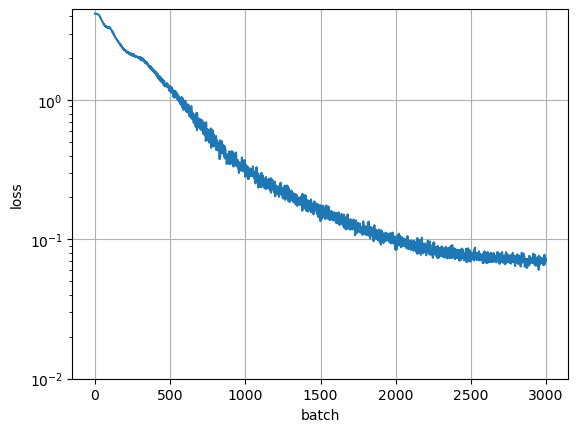

In [16]:
plt.plot(np.array(loss_list))

# plt.xlim(1, 1e5)
plt.ylim(0.01,4.5)
plt.yscale('log')
# plt.xscale('log')
plt.ylabel('loss')
plt.xlabel('batch')
plt.grid()
plt.show()

In [17]:
@torch.no_grad()
def generate(model, context, kernel_size, N_gen, temp=1.0):
    
    model.eval()
    
    context = context.unsqueeze(0)
    output = context.clone()
    
    for _ in range(N_gen):
        context = output[:, -kernel_size:]
        logits = model(context)
        logits = logits[:,-1,:]
        
        if temp > 0.0:
        
            probabilities = tnf.softmax(logits/temp, dim=-1)
            idx_next = torch.multinomial(probabilities, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1).view(1,-1)
            
        output = torch.cat((output, idx_next), dim=1)
        
    return output[0]

torch.cuda.empty_cache()

gen_output = torch.tensor(encode(text[-context_length:])).to(device)

gen_output = generate(model, gen_output, context_length, 5*context_length, temp=1.0)

print(decode(gen_output.cpu().numpy()))

you, sir,
Do not omit the heavy offer of it:
It seldom visits sorrow; when it doth,
It is a comforter.

ANTONIO:
We two, my lord,
Will guard your person while you take your rest,
And watch your safety.

ALONSO:
Thank you. Wondrous heavy.

SEBASTIAN:
What a strange drowsiness possesses them!

ANTONIO:
It is the quality o' the climate.

SEBASTIAN:
Why
Doth it not then our eyelids sink? I find not
Myself disposed to sleep.

ANTONIO:
Nor I; my spirits are nimble.
They fell together all, as by consent;
They dropp'd, as by a thunder-stroke. What might,
Worthy Sebastian? O, what might?--No more:--
And yet me thinks I see it in thy face,
What thou shouldst be: the occasion speaks thee, and
My strong imagination sees a crown
Dropping upon thy head.

SEBASTIAN:
What, art thou waking?

ANTONIO:
Do you not hear me speak?

SEBASTIAN:
I do; and surely
It is a sleepy language and thou speak'st
Out of thy sleep. What is it thou didst say?
This is a strange repose, to be asleep
With eyes wide open; sta